# Optimalizace dispečinku bateriového úložiště pro energetickou arbitráž a ořezávání špiček

## Shrnutí pro vedení

Komerční areál připojený k síti provozuje lithium-iontovou baterii 2 MW / 8 MWh vedle měřené elektrické zátěže. Areál je účtován dvěma způsoby: hodinovou **cenou energie** na denním trhu ($/MWh) a měsíční **platbou za rezervovaný příkon** za svůj jediný nejvyšší interval odběru ze sítě ($/MW). Správce aktiva musí hodinu po hodině rozhodovat, kdy baterii nabíjet (nákup levné energie a zvyšování odběru ze sítě) a kdy ji vybíjet (kompenzace drahé energie a snižování odběru ze sítě). Soupeří dva zdroje hodnoty: **energetická arbitráž** (nakup levně přes noc, vybíjej při večerní špičce) a **ořezávání špiček** (zastropuj účtované maximum odběru ze sítě). Nabíjení není zdarma — účinnost tam a zpět znamená, že zhruba 10 % uložené energie se ztratí — takže rozvrh je skutečná optimalizace, nikoli heuristika.

Tento notebook sestavuje rozhodnutí od začátku do konce. Nejprve syntetizuje realistickou 24hodinovou křivku ceny na denním trhu (s ranní a večerní špičkou plus nočním minimem) a korelovaný profil zátěže areálu, poté oba profiluje pomocí **PROC MEANS** a robustního pásma cen 2.5/97.5 percentilu z **PROC UNIVARIATE**. Jádrem je lineární program v **PROC OPTMODEL**: rozhodovací proměnné pro hodinové nabíjení, vybíjení a stav nabití, plus proměnná účtované špičky, podléhající kumulativní bilanci stavu nabití (se samostatnou účinností nabíjení/vybíjení), výkonovým a kapacitním limitům a omezení definice špičky. Účelová funkce maximalizuje arbitrážní marži po odečtení platby za rezervovaný příkon. **PROC SQL** poté kvantifikuje náklady základního scénáře versus optimalizovaného a tři panely **PROC SGPLOT** vizualizují rozvrh nabíjení/vybíjení proti ceně, trajektorii stavu nabití a zploštělý profil odběru ze sítě.

**Výsledek na syntetickém dni:** optimalizátor plní baterii během nejlevnějších nočních hodin, vybíjí do ranní i večerní cenové špičky, dobíjí přes polední cenové údolí a — zásadně — drží svůj nabíjecí výkon zpět, takže nikdy nevytvoří novou špičku odběru ze sítě. Denní náklady na energii klesají z **\$2,903.78 na \$2,528.43** — **\$375.34 (12.9%) arbitrážní úspory** — zatímco účtované maximum odběru ze sítě klesá z **3.59 MW na 3.43 MW** (asi **0.16 MW**), což má hodnotu dalších **\$18.98** při předpokládané denní části platby za rezervovaný příkon. Stejný model se škáluje na delší horizonty, více cenových scénářů nebo cyklování zohledňující degradaci jednoduše rozšířením indexové množiny a omezení.

## Zdroje dat

Všechna data jsou **syntetická**, generovaná uvnitř první kódové buňky pomocí `CALL STREAMINIT(20260605)` pro reprodukovatelnost. Žádné externí soubory ani přístup k síti. Jedna datová sada, `price_load`, s 24 hodinovými řádky představujícími jediný provozní den.

| Proměnná | Typ | Jednotky | Popis |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Hodina provozního dne (index horizontu) |
| `price` | num | $/MWh | Cena energie na denním trhu: noční minimum, ranní + večerní špičky, s gaussovským šumem (dolní mez $5) |
| `load` | num | MW | Elektrická poptávka areálu, korelovaná s denní aktivitou (dolní mez 0.3 MW) |
| `day_type` | char | — | Příznak tarifního okna: `PeakTOU` (hodiny 17–21) vs `OffPeak`, použitý pro souhrn cenového rozpětí špička/mimo špičku |

Parametry baterie jsou pevné konstanty modelu uvnitř PROC OPTMODEL: 8 MWh využitelná kapacita, 2 MW maximální nabíjecí/vybíjecí výkon, 0.95 účinnost nabíjení a 0.95 účinnost vybíjení (~90 % tam a zpět), počáteční stav nabití 0 MWh a platba za rezervovaný příkon \$120/MW aplikovaná na denní účtovanou špičku odběru ze sítě (denně amortizovaná část měsíční platby za rezervovaný příkon).

# Optimalizace dispečinku bateriového úložiště
## Energetická arbitráž a ořezávání špiček pro areál připojený k síti

Komerční areál provozuje **baterii 2 MW / 8 MWh** za svým elektroměrem. Jeho účet za elektřinu má dvě části: hodinovou **cenu energie** ($/MWh) a měsíční **platbu za rezervovaný příkon** za jediný nejvyšší interval odběru ze sítě ($/MW). Provozovatel chce hodinový rozvrh nabíjení/vybíjení, který zachytí dva zdroje hodnoty najednou:

- **Arbitráž** — uskladni levnou noční energii, uvolni ji během drahých špičkových hodin.
- **Ořezávání špiček** — vybíjej během špičky poptávky ke snížení účtovaného maxima odběru ze sítě.

Protože účinnost tam a zpět ztrácí ~10 % uložené energie, je tento kompromis netriviální a zaslouží si skutečnou optimalizaci. Formulujeme jej jako lineární program v **PROC OPTMODEL**, poté výsledek kvantifikujeme a vizualizujeme.

> Všechna data níže jsou syntetická a generovaná uvnitř notebooku — notebook je plně soběstačný a běží několik sekund.

## 1. Vygenerování syntetického profilu ceny na denním trhu a zátěže

Sestavujeme jeden provozní den (24 hodinových řádků). Cenová křivka má noční minimum a ranní + večerní špičky; zátěž areálu je korelovaná s denní aktivitou. Pevné semínko udržuje běh reprodukovatelný. Rovněž značíme zákonné okno špičky podle času použití (time-of-use), abychom mohli později shrnout rozpětí špička/mimo špičku.

In [1]:
data price_load;
    CALL streaminit(20260605);
    DÉLKA day_type $16;
    OPAKUJ hour = 0 TO 23;
        /* Denní profil ceny energie ($/MWh): ranní + večerní špička */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        KDYŽ price < 5 PAK price = 5;

        /* Zátěž areálu (MW): noční minimum, večerní nárůst */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        KDYŽ LOAD < 0.3 PAK LOAD = 0.3;

        KDYŽ hour >= 17 AND hour <= 21 PAK day_type = 'Špička';
        JINAK day_type = 'Mimo špičku';
        VÝSTUP;
    KONEC;
    ODSTRANIT BASE;
    ŠTÍTEK price='Cena ($/MWh)' LOAD='Zátěž (MW)' hour='Hodina'
          day_type='Typ období';
SPUSTIT;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profilování rozdělení ceny a zátěže

Před optimalizací provádíme kontrolu vstupů. Rozpětí mezi nejlevnějšími a nejdražšími hodinami je to, co arbitráž zpeněžuje, a maximální zátěž ukotvuje příležitost ořezávání špiček.

In [2]:
NÁZEV "Rozdělení ceny a zátěže";
PROCEDURA PRŮMĚRY data=price_load n mean std MIN MAX maxdec=2;
    PROMĚNNÁ price LOAD;
SPUSTIT;
NÁZEV;

                                                Rozdělení ceny a zátěže                                                 

                                                  The MEANS Procedure

 Variable  Label                N        Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------------------
 price     Cena ($/MWh)        24       46.29       15.81       18.57       79.27
 LOAD      Zátěž (MW)          24        2.47        0.48        1.71        3.59
 --------------------------------------------------------------------------------




NOTE: Option TITLE changed to Rozdělení ceny a zátěže.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Cenové rozpětí špička vs mimo špičku

Seskupení podle příznaku času použití ukazuje, oč bohatší jsou špičkové hodiny než základní hladina mimo špičku — strukturální signál, který baterie využívá.

In [3]:
NÁZEV "Cena podle typu období";
PROCEDURA PRŮMĚRY data=price_load mean MIN MAX maxdec=2;
    TŘÍDA day_type;
    PROMĚNNÁ price;
SPUSTIT;
NÁZEV;

                                                 Cena podle typu období                                                 

                                                  The MEANS Procedure

                                        Analysis Variable : price Cena ($/MWh)

                                                  N
                               Typ období       Obs       Mean      Minimum      Maximum
                               ---------------------------------------------------------
                               Mimo špičku       19      40.46        18.57        54.89
                               Špička             5      68.45        54.88        79.27
                               ---------------------------------------------------------




NOTE: Option TITLE changed to Cena podle typu období.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robustní cenové pásmo (2.5 / 97.5 percentil)

Charakterizujeme konce cen pásmem 2.5 / 97.5 percentilu. **PROC UNIVARIATE** s `PCTLPTS=` počítá libovolné percentily čistě, což je správný nástroj pro zlomkové percentily.

In [4]:
NÁZEV "Robustní cenové pásmo (2,5 / 97,5 percentil)";
PROCEDURA UNIVARIATE data=price_load NOPRINT;
    PROMĚNNÁ price;
    VÝSTUP out=price_band pctlpts=2.5 97.5 pctlpre=p_;
SPUSTIT;

PROCEDURA TISK data=price_band noobs;
SPUSTIT;
NÁZEV;

                                      Robustní cenové pásmo (2,5 / 97,5 percentil)                                      


P_2_5  P_97_5
-----  ------
18.57   79.27




NOTE: Option TITLE changed to Robustní cenové pásmo (2,5 / 97,5 percentil).
NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Optimalizace dispečinku (lineární program)

Načítáme hodinovou cenu a zátěž do PROC OPTMODEL a deklarujeme:

- `chg[h]`, `dis[h]` — hodinový nabíjecí / vybíjecí výkon (MW), omezený jmenovitým výkonem střídače 2 MW.
- `soc[h]` — stav nabití (MWh), omezený využitelnou kapacitou 8 MWh.
- `peak` — účtované maximum odběru ze sítě (MW).

**Omezení.** `soc_balance` akumuluje čistou energii přes každou hodinu se samostatnou účinností nabíjení/vybíjení (forma běžícího součtu hodinové rekurence). `peak_def` nutí `peak`, aby dominoval čistému odběru ze sítě v každé hodině, takže jeho minimalizace ořezává platbu za rezervovaný příkon.

**Účelová funkce.** Maximalizuj arbitrážní marži — `price × (discharge − charge)` sečtenou přes den — mínus platba za rezervovaný příkon za účtovanou špičku. Řešíme jako spojitý LP.

In [5]:
PROCEDURA optmodel;
    NASTAVIT HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ data price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Baterie: 8 MWh využitelných, 2 MW výkon, ~90% účinnost cyklu */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Poplatek za výkon aplikovaný na dnešní účtovanou špičku sítě ($/MW).
       Komerční poplatky za výkon jsou měsíční; 120 je mezní hodnota
       oříznutí dnešního maxima sítě po rozpuštění měsíčního poplatku na den.
       Je dost velký, aby optimalizátor raději zdržel nabíjecí výkon, než
       aby vytvořil novou, vyšší špičku. */
    num demand_chg = 120;

    /* Rozhodovací proměnné (MW nabíjení / vybíjení, MWh stav nabití) */
    PROMĚNNÁ chg{HOURS}  >= 0 <= p_max;
    PROMĚNNÁ dis{HOURS}  >= 0 <= p_max;
    PROMĚNNÁ soc{HOURS}  >= 0 <= capacity;
    PROMĚNNÁ peak        >= 0;   /* účtovaná špička sítě (MW) pro poplatek za výkon */

    /* Čistý odběr ze sítě po zásahu baterie (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Kumulativní stav nabití: energie dodaná minus odebraná do hodiny h,
       s uplatněnou účinností nabíjení/vybíjení. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Oříznutí špičky: účtovaná špička je maximum odběru ze sítě za den */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Maximalizace marže z energetické arbitráže po odečtení poplatku za výkon */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE data dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Optimální hodinový rozvrh

Vyřešená tabulka ukazuje nabíjení rozprostřené přes levné noční a polední hodiny — mírněné zhruba na 1.0–1.7 MW, takže nikdy nenastaví novou špičku odběru ze sítě — vybíjení soustředěné do ranní a večerní cenové špičky a stav nabití vykreslující smysluplný cyklus naplnění a uvolnění v rámci stropu 8 MWh. Sloupec `grid_mw` drží plochý strop ~3.43 MW přes každou nabíjecí hodinu, což je podpis závazného omezení špičky.

In [6]:
NÁZEV "Optimální hodinový rozvrh";
PROCEDURA TISK data=dispatch noobs ŠTÍTEK;
    PROMĚNNÁ hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ŠTÍTEK hour='Hodina' price='Cena ($/MWh)' LOAD='Zátěž (MW)'
          charge_mw='Nabíjení (MW)' discharge_mw='Vybíjení (MW)'
          soc_mwh='Stav nabití (MWh)' grid_mw='Odběr ze sítě (MW)';
SPUSTIT;
NÁZEV;

                                               Optimální hodinový rozvrh                                                


Hodina  Cena ($/MWh)     Zátěž (MW)    Nabíjení (MW)    Vybíjení (MW)   Stav nabití (MWh)     Odběr ze sítě (MW)
------  ------------  -------------  ---------------  ---------------  ------------------  ---------------------
     0         29.73           1.99        1.4418421                0             1.36975              3.4318421
     1         28.03           2.16        1.2718421                0               2.578              3.4318421
     2         21.87              2        1.4318421                0             3.93825              3.4318421
     3         18.57           1.71        1.7218421                0               5.574              3.4318421
     4         27.62           2.13        1.3018421                0             6.81075              3.4318421
     5         36.12           2.18        1.2518421                0                 


NOTE: Option TITLE changed to Optimální hodinový rozvrh.
NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Titulní KPI: základní scénář vs optimalizovaný

Porovnáváme nečinný základní scénář (plať cenu za surovou zátěž každou hodinu) proti optimalizované síťové pozici a vykazujeme arbitrážní úspory, snížení účtované špičky a peněžní hodnotu tohoto snížení při platbě za rezervovaný příkon — dvě páky, které pohánějí obchodní případ.

In [7]:
PROCEDURA SQL;
    CREATE TABLE kpi AS
    VYBRAT
        sum(price * LOAD)                        AS base_energy_cost
            ŠTÍTEK='Základní náklady na energii ($)',
        sum(price * grid_mw)                     AS opt_energy_cost
            ŠTÍTEK='Optimalizované náklady na energii ($)',
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings
            ŠTÍTEK='Úspora z arbitráže ($)',
        MAX(LOAD)                                AS base_peak_mw
            ŠTÍTEK='Základní špička (MW)',
        MAX(grid_mw)                             AS opt_peak_mw
            ŠTÍTEK='Optimalizovaná špička (MW)',
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw
            ŠTÍTEK='Snížení špičky (MW)',
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
            ŠTÍTEK='Úspora z poplatku za výkon ($)'
    FROM dispatch;
QUIT;

NÁZEV "Klíčové ukazatele: základní scénář vs optimalizovaný";
PROCEDURA TISK data=kpi noobs ŠTÍTEK;
SPUSTIT;
NÁZEV;

                                  Klíčové ukazatele: základní scénář vs optimalizovaný                                  


   Základní náklady na energii ($)    Optimalizované náklady na energii ($)     Úspora z arbitráže ($)      Základní špička (MW)     Optimalizovaná špička (MW)       Snížení špičky (MW)    Úspora z poplatku za výkon ($)
----------------------------------  ---------------------------------------  -------------------------  ------------------------  -----------------------------  ------------------------  --------------------------------
                         2903.7774                          2528.4335145526             375.3438854474                      3.59                      3.4318421                 0.1581579                         18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: Option TITLE changed to Klíčové ukazatele: základní scénář vs optimalizovaný.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Rozvrh nabíjení / vybíjení proti ceně

Nabíjení (modré jehly) a vybíjení (červená čára se značkami) sdílejí levou osu megawattů; cena na denním trhu (zelená přerušovaná) se čte na pravé ose. Nabíjení se shlukuje v levných nočních a poledních hodinách, zatímco vybíjení pálí do ranní a večerní cenové špičky — vizuál potvrzuje, že optimalizátor nakupuje levně a prodává draze.

                                         Rozvrh nabíjení / vybíjení proti ceně                                          




NOTE: Option TITLE changed to Rozvrh nabíjení / vybíjení proti ceně.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


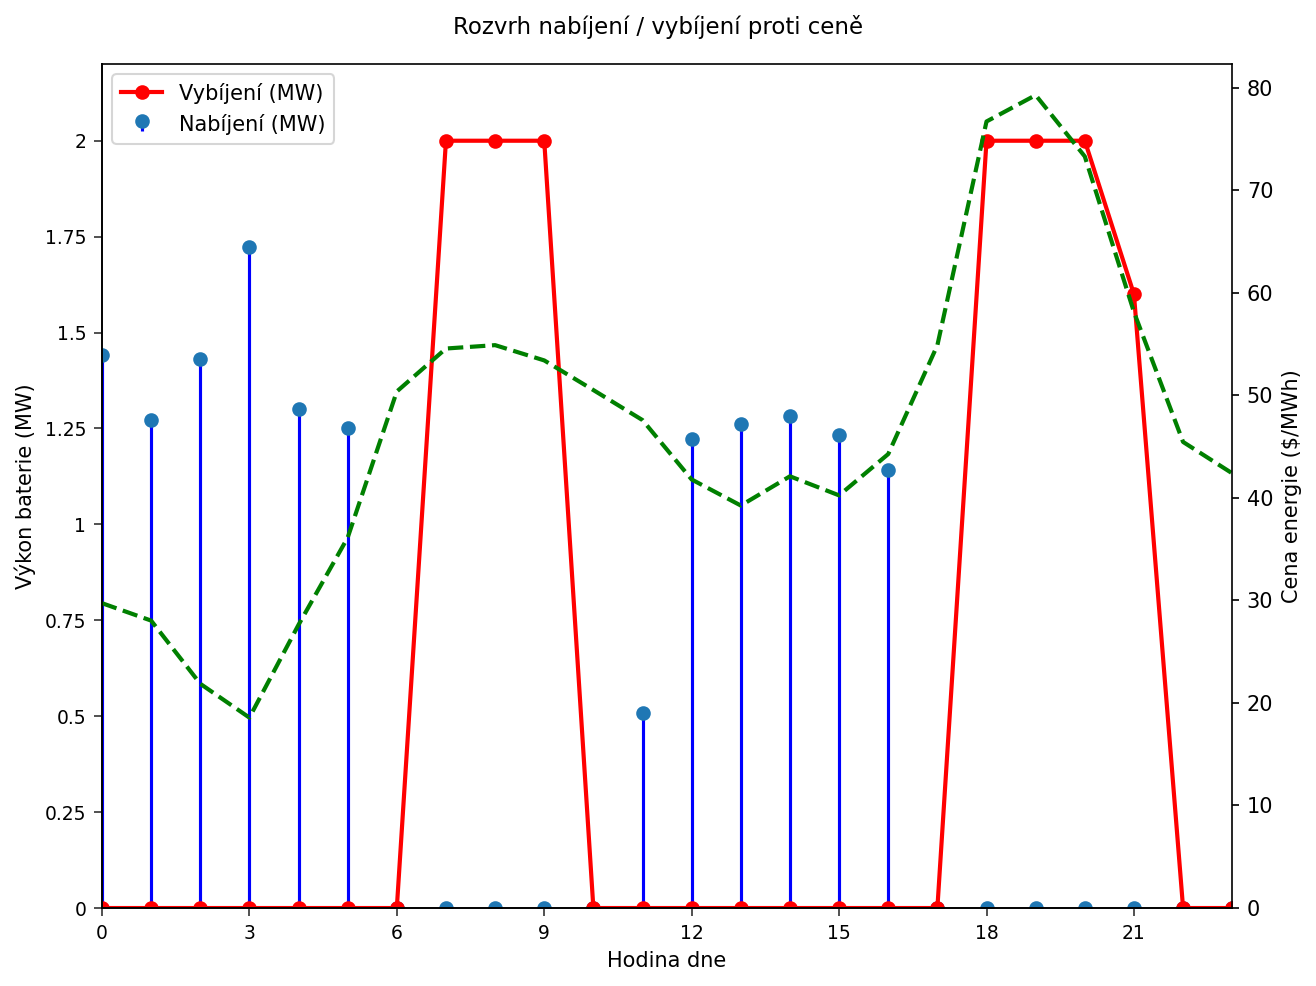

In [8]:
NÁZEV "Rozvrh nabíjení / vybíjení proti ceně";
PROCEDURA SGPLOT data=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Nabíjení (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Vybíjení (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Cena ($/MWh)";
    XAXIS ŠTÍTEK="Hodina dne" VALUES=(0 TO 23 PODLE 3);
    YAXIS ŠTÍTEK="Výkon baterie (MW)" MIN=0 MAX=2.2;
    y2axis ŠTÍTEK="Cena energie ($/MWh)" MIN=0;
SPUSTIT;
NÁZEV;

## 9. Trajektorie stavu nabití

Uložená energie stoupá, jak se baterie přes noc plní, klesá přes každé okno vybíjení a nikdy neporuší strop využitelné kapacity 8 MWh (tečkovaná reference).

                                                Trajektorie stavu nabití                                                




NOTE: Option TITLE changed to Trajektorie stavu nabití.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


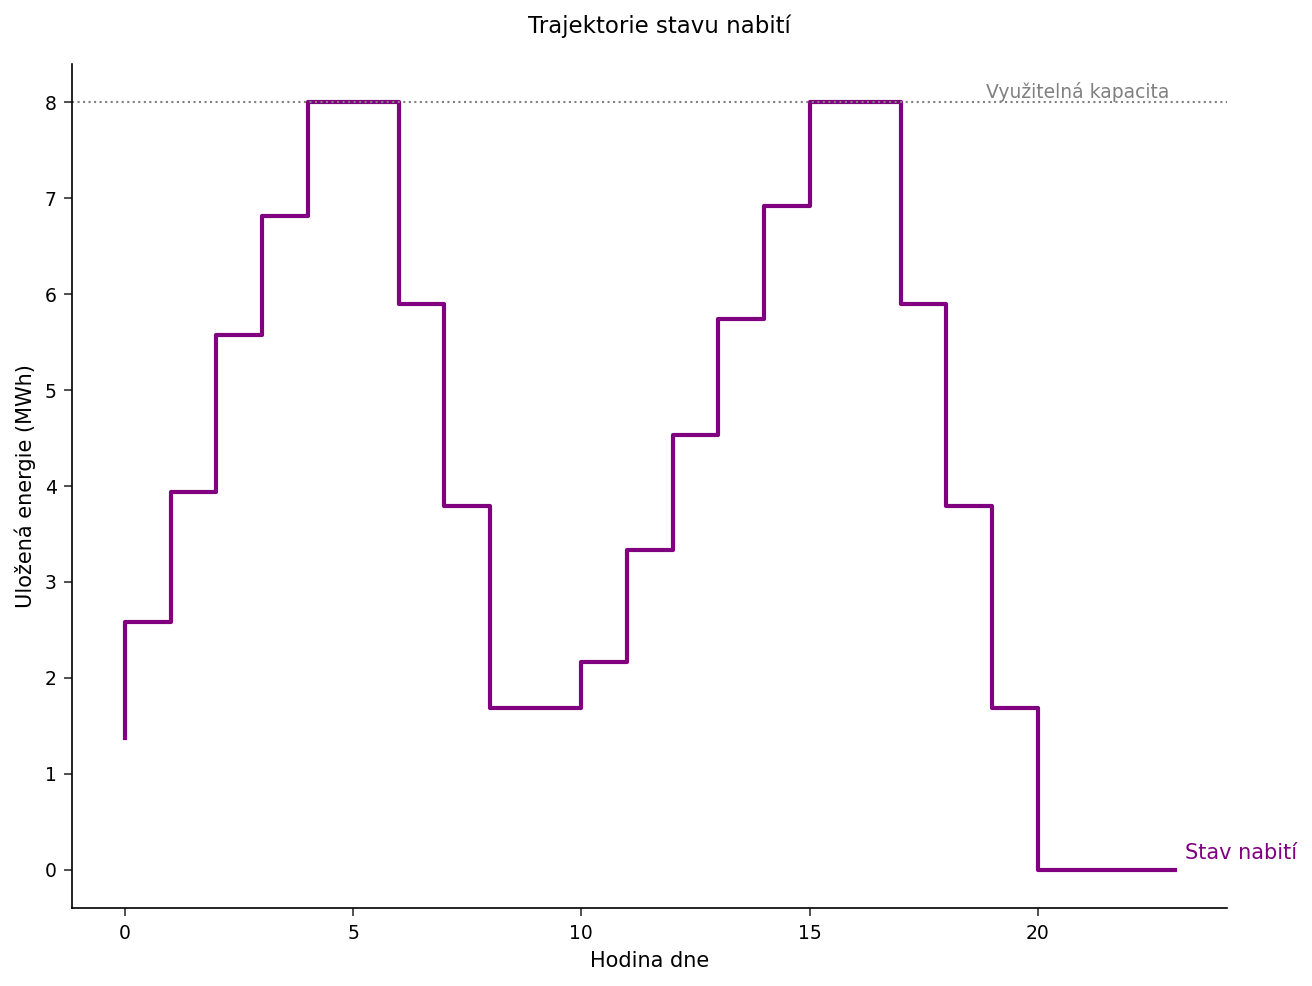

In [9]:
NÁZEV "Trajektorie stavu nabití";
PROCEDURA SGPLOT data=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Stav nabití";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ŠTÍTEK="Využitelná kapacita";
    XAXIS ŠTÍTEK="Hodina dne";
    YAXIS ŠTÍTEK="Uložená energie (MWh)";
SPUSTIT;
NÁZEV;

## 10. Odběr ze sítě: před vs po dispečinku

Oranžová čára (odběr ze sítě s baterií) klesá výrazně pod přerušovanou základní zátěž během večerního nárůstu (hodiny 18–21) — efekt ořezávání špiček, který snižuje platbu za rezervovaný příkon. Během nočních a poledních nabíjecích oken stoupá, ale optimalizátor jej zastropuje na plochém stropu ~3.43 MW, který zůstává *pod* původní špičkou zátěže 3.59 MW, takže nabíjení nakupuje levnou energii, aniž by nastavilo nové účtované maximum.

                                          Odběr ze sítě: před vs po dispečinku                                          




NOTE: Option TITLE changed to Odběr ze sítě: před vs po dispečinku.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


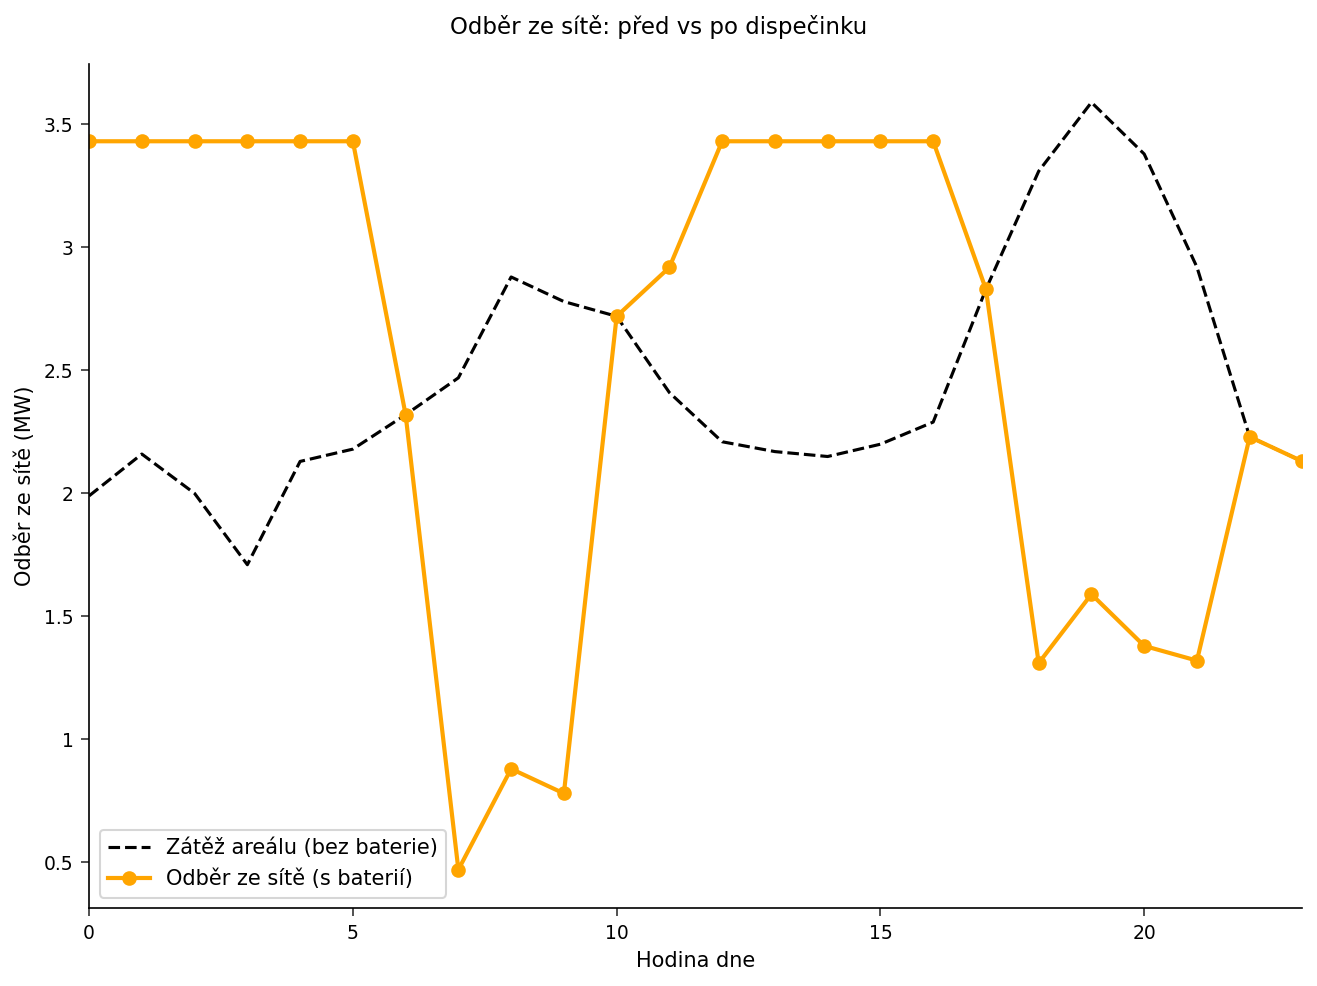

In [10]:
NÁZEV "Odběr ze sítě: před vs po dispečinku";
PROCEDURA SGPLOT data=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Zátěž areálu (bez baterie)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Odběr ze sítě (s baterií)";
    XAXIS ŠTÍTEK="Hodina dne";
    YAXIS ŠTÍTEK="Odběr ze sítě (MW)";
SPUSTIT;
NÁZEV;

## Interpretace a další kroky

**Co model rozhodl.** Přestože účinnost tam a zpět zdaňuje každý cyklus, optimalizátor přesto našel jasnou hodnotu: naplnil baterii během nejlevnějších nočních hodin, vybil do ranní cenové špičky (hodiny 7–9), dobil přes polední cenové údolí (hodiny 11–16) a znovu vybil do nejbohatší večerní špičky (hodiny 18–21). Příznačně nabíjel jen na 1.0–1.7 MW namísto plného jmenovitého výkonu 2 MW během nočního plnění — držel výkon zpět, aby přidaný odběr ze sítě nikdy netlačil odběr nad denní špičku zátěže. Stav nabití vždy respektoval jak kapacitu 8 MWh, tak výkonový limit 2 MW.

**Obchodní případ.** Denní náklady na energii klesly z **\$2,903.78 na \$2,528.43** — **\$375.34 (12.9%)** arbitrážní úspory — a účtované maximum odběru ze sítě kleslo z **3.59 MW na 3.43 MW** (asi **0.16 MW**), čímž se z položky platby za rezervovaný příkon ubralo dalších **\$18.98**. Anualizováno napříč provozními dny plus opakující se snížení platby za rezervovaný příkon jde o typ marže, který podpírá investici do úložiště.

**Proč je LP správným nástrojem.** Heuristiky („nabíjej pod mediánovou cenou, vybíjej nad ní") ignorují ztráty účinnosti, kapacitní provázání napříč hodinami a fakt, že platba za rezervovaný příkon závisí na jediném intervalu — nabíjely by plným výkonem přes noc a *zvýšily* by účtovanou špičku, čímž by zničily hodnotu ořezávání špiček. PROC OPTMODEL zachycuje všechny tyto aspekty v jednom deklarativním modelu a vrací prokazatelně optimální rozvrh, který zde záměrně mírní rychlost nabíjení, aby ochránil špičku.

**Rozšíření modelu.**

- **Delší horizonty / více dní** — rozšiř indexovou množinu `HOURS`; přidej limity mezidenního cyklování.
- **Cenová nejistota** — vyřeš LP napříč více cenovými scénáři a zprůměruj rozhodnutí první hodiny (klouzavá stochastická politika).
- **Degradace baterie** — přidej člen penalizace za průtok nebo omezení na kumulativní cykly pro obchodování arbitráže proti životnosti aktiva.
- **Frekvenční regulace / kapacitní trhy** — zaveď omezení rezervované rezervy, aby baterie mohla naskládat výnosy z podpůrných služeb nad arbitráž.

Všechna tato rozšíření jsou přírůstkové úpravy téhož bloku OPTMODEL — struktura zde ustanovená se přenáší beze změny.